In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/customer_cohort_dataset.csv')

# Convert date column to proper datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

print("Data loaded!")
print("Date range:", df['Order_Date'].min(), "to", df['Order_Date'].max())
print("Shape:", df.shape)

Data loaded!
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00
Shape: (3000, 10)


In [2]:
# Last date in dataset = reference point
reference_date = df['Order_Date'].max()
print("Reference date:", reference_date)

# Last purchase date per customer
last_purchase = df.groupby('Customer_ID')['Order_Date'].max().reset_index()
last_purchase.columns = ['Customer_ID', 'Last_Purchase_Date']

# Days since last purchase
last_purchase['Days_Since_Purchase'] = (reference_date - last_purchase['Last_Purchase_Date']).dt.days

# Churn = no purchase in last 90 days (3 months)
last_purchase['Churned'] = (last_purchase['Days_Since_Purchase'] > 90).astype(int)

print("\n=== CHURN DISTRIBUTION ===")
print(last_purchase['Churned'].value_counts())
print("\nChurn Rate:", round(last_purchase['Churned'].mean() * 100, 2), "%")

Reference date: 2023-12-31 00:00:00

=== CHURN DISTRIBUTION ===
Churned
0    453
1    141
Name: count, dtype: int64

Churn Rate: 23.74 %


In [3]:
# RECENCY — days since last purchase
recency = last_purchase[['Customer_ID', 'Days_Since_Purchase']].copy()
recency.columns = ['Customer_ID', 'Recency']

# FREQUENCY — total number of orders
frequency = df.groupby('Customer_ID')['Order_ID'].count().reset_index()
frequency.columns = ['Customer_ID', 'Frequency']

# MONETARY — total revenue spent
monetary = df.groupby('Customer_ID')['Revenue'].sum().reset_index()
monetary.columns = ['Customer_ID', 'Monetary']

# Merge all RFM together
rfm = recency.merge(frequency, on='Customer_ID').merge(monetary, on='Customer_ID')

print("RFM Features created!")
print(rfm.head())
print("\nShape:", rfm.shape)

RFM Features created!
  Customer_ID  Recency  Frequency  Monetary
0       C0001      130          5      4232
1       C0002      132          3      4234
2       C0003      107          7      5641
3       C0004      211          2      2172
4       C0005      147          6      6358

Shape: (594, 4)


In [4]:
# Average order value
avg_order = df.groupby('Customer_ID')['Revenue'].mean().reset_index()
avg_order.columns = ['Customer_ID', 'Avg_Order_Value']

# Total quantity purchased
total_qty = df.groupby('Customer_ID')['Quantity'].sum().reset_index()
total_qty.columns = ['Customer_ID', 'Total_Quantity']

# Favourite category (most ordered)
fav_category = df.groupby(['Customer_ID', 'Category'])['Order_ID'].count().reset_index()
fav_category = fav_category.loc[fav_category.groupby('Customer_ID')['Order_ID'].idxmax()]
fav_category = fav_category[['Customer_ID', 'Category']].rename(columns={'Category': 'Fav_Category'})

# Favourite region
fav_region = df.groupby('Customer_ID')['Region'].agg(lambda x: x.mode()[0]).reset_index()
fav_region.columns = ['Customer_ID', 'Region']

# Merge everything
customer_df = rfm.merge(avg_order, on='Customer_ID')\
                  .merge(total_qty, on='Customer_ID')\
                  .merge(fav_category, on='Customer_ID')\
                  .merge(fav_region, on='Customer_ID')

print("All features created!")
print(customer_df.head())
print("\nShape:", customer_df.shape)
print("\nColumns:", customer_df.columns.tolist())

All features created!
  Customer_ID  Recency  Frequency  Monetary  Avg_Order_Value  Total_Quantity  \
0       C0001      130          5      4232       846.400000              10   
1       C0002      132          3      4234      1411.333333               6   
2       C0003      107          7      5641       805.857143               8   
3       C0004      211          2      2172      1086.000000               4   
4       C0005      147          6      6358      1059.666667              14   

  Fav_Category Region  
0  Electronics  North  
1       Office  North  
2  Accessories   East  
3  Accessories   East  
4  Electronics   East  

Shape: (594, 8)

Columns: ['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Total_Quantity', 'Fav_Category', 'Region']


In [5]:
# Add churn label
customer_df = customer_df.merge(
    last_purchase[['Customer_ID', 'Churned']], 
    on='Customer_ID'
)

print("Churn label added!")
print("\n=== FINAL DATASET ===")
print(customer_df.shape)
print(customer_df.head())

print("\n=== CHURN BREAKDOWN ===")
print("Not Churned (0):", (customer_df['Churned'] == 0).sum())
print("Churned (1)    :", (customer_df['Churned'] == 1).sum())
print("Churn Rate     :", round(customer_df['Churned'].mean() * 100, 2), "%")

Churn label added!

=== FINAL DATASET ===
(594, 9)
  Customer_ID  Recency  Frequency  Monetary  Avg_Order_Value  Total_Quantity  \
0       C0001      130          5      4232       846.400000              10   
1       C0002      132          3      4234      1411.333333               6   
2       C0003      107          7      5641       805.857143               8   
3       C0004      211          2      2172      1086.000000               4   
4       C0005      147          6      6358      1059.666667              14   

  Fav_Category Region  Churned  
0  Electronics  North        1  
1       Office  North        1  
2  Accessories   East        1  
3  Accessories   East        1  
4  Electronics   East        1  

=== CHURN BREAKDOWN ===
Not Churned (0): 453
Churned (1)    : 141
Churn Rate     : 23.74 %


C:\Users\User\AppData\Local\Temp\ipykernel_22952\40737130.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([churned_0, churned_1], labels=['Not Churned', 'Churned'],
C:\Users\User\AppData\Local\Temp\ipykernel_22952\40737130.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([freq_0, freq_1], labels=['Not Churned', 'Churned'],


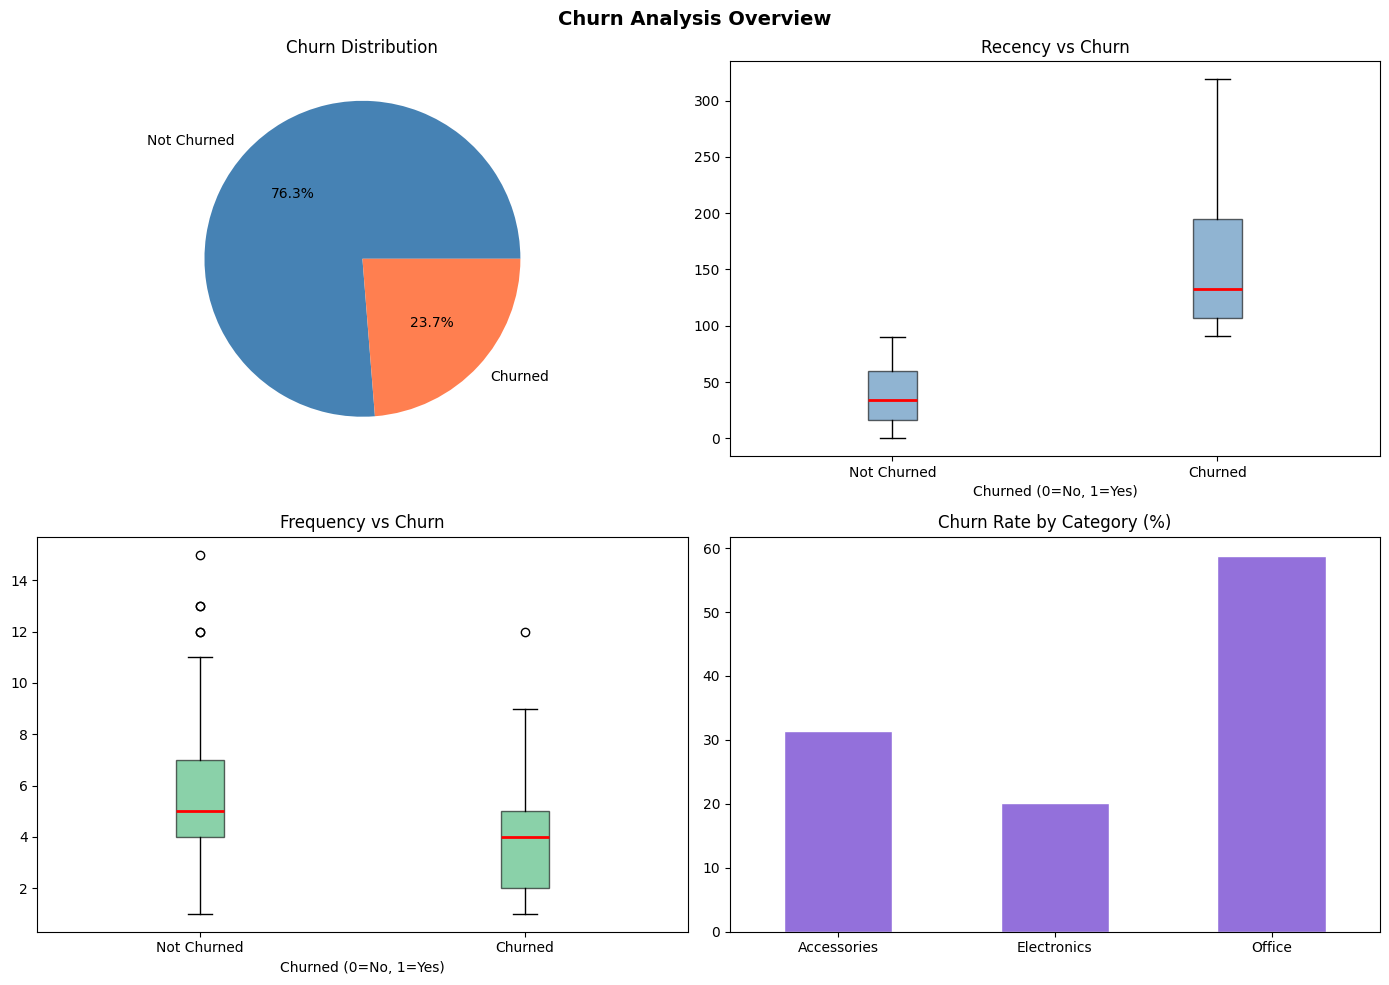

Churn analysis charts saved!


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analysis Overview', fontsize=14, fontweight='bold')

# Churn distribution
customer_df['Churned'].value_counts().plot(
    kind='pie', ax=axes[0,0], autopct='%1.1f%%',
    labels=['Not Churned', 'Churned'],
    colors=['steelblue', 'coral']
)
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_ylabel('')

# Recency vs Churn — FIXED
churned_0 = customer_df[customer_df['Churned'] == 0]['Recency']
churned_1 = customer_df[customer_df['Churned'] == 1]['Recency']
axes[0,1].boxplot([churned_0, churned_1], labels=['Not Churned', 'Churned'],
                   patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[0,1].set_title('Recency vs Churn')
axes[0,1].set_xlabel('Churned (0=No, 1=Yes)')

# Frequency vs Churn — FIXED
freq_0 = customer_df[customer_df['Churned'] == 0]['Frequency']
freq_1 = customer_df[customer_df['Churned'] == 1]['Frequency']
axes[1,0].boxplot([freq_0, freq_1], labels=['Not Churned', 'Churned'],
                   patch_artist=True,
                   boxprops=dict(facecolor='mediumseagreen', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Frequency vs Churn')
axes[1,0].set_xlabel('Churned (0=No, 1=Yes)')

# Churn by Category
churn_cat = customer_df.groupby('Fav_Category')['Churned'].mean() * 100
churn_cat.plot(kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Churn Rate by Category (%)')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Churn analysis charts saved!")

In [9]:
customer_df.to_csv('../data/customer_features.csv', index=False)
print("Final dataset saved as customer_features.csv!")
print("Shape:", customer_df.shape)
print("\nFinal columns:")
for col in customer_df.columns:
    print(" →", col)

Final dataset saved as customer_features.csv!
Shape: (594, 9)

Final columns:
 → Customer_ID
 → Recency
 → Frequency
 → Monetary
 → Avg_Order_Value
 → Total_Quantity
 → Fav_Category
 → Region
 → Churned
